INSTALL DEPENDECIES (NLTK)

In [ ]:
#!pip install nltk contractions -q
#!pip install gradio -q
#!pip install groq -q
#!pip install sentence-transformers rank-bm25

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 5.6 MB/s eta 0:00:00


IMPORT FUNCTIONS

In [1]:
import pandas as pd
import re
import unicodedata
import nltk
import contractions

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

DOWNLOAD NLTK RESOURCES

In [2]:
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Prestige\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Prestige\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Prestige\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

LOAD DATASETS (GOOGLE REVIEWS BY APIFY)

In [3]:
df = pd.read_csv(
    'GoogleMapsReviewsCafe_Raw_MergedALL.csv',
    encoding='utf-8',
    on_bad_lines='skip',
    engine='python',
)

df = df.dropna(subset=['stars']).copy()

print(f"Total reviews loaded: {len(df)}")
print(f"Tipe kolom stars: {df['stars'].dtype}")
print(df.head(3))

Total reviews loaded: 5860
Tipe kolom stars: int64
           title                                                url  stars  \
0  9 Cups Coffee  https://www.google.com/maps/search/?api=1&quer...      5   
1  9 Cups Coffee  https://www.google.com/maps/search/?api=1&quer...      5   
2  9 Cups Coffee  https://www.google.com/maps/search/?api=1&quer...      4   

           name                                          reviewUrl  \
0    Arya Twirl  https://www.google.com/maps/reviews/data=!4m8!...   
1  Jane Wirawan  https://www.google.com/maps/reviews/data=!4m8!...   
2   Rio Rinaldo  https://www.google.com/maps/reviews/data=!4m8!...   

                                                text  
0  Probably the most homey coffee shop I've been ...  
1  Good coffee, small cozy cafe. There are two fl...  
2  A really satisfactory find in the neighborhood...  


SETUP TOOLS, STOPWORDS & SLANG

In [4]:
lemmatizer = WordNetLemmatizer()

# Stopwords cafe/review
domain_stopwords = {
    "place", "go", "went", "come", "came", "get", "got", "back",
    "try", "tried", "want", "wanted", "really", "always", "never",
    "also", "just", "even", "still", "time", "day", "night",
    "cafe", "coffee", "shop", "restaurant", "spot",
    "good", "great", "nice", "bad", "okay", "ok", "bit",
    "lot", "lots", "little", "pretty", "quite", "very",
    "definitely", "highly", "absolutely", "totally",
    "ordered", "order", "visit", "visited", "recommend",
    "experience", "staff", "table", "seat", "seated",
}

all_stopwords = set(ENGLISH_STOP_WORDS) | domain_stopwords

# Kamus slang/typo seputarcafe
slang_dict = {
    "delish":  "delicious", "yummy":    "delicious",
    "yum":     "delicious", "cozy":     "cozy",
    "cozzy":   "cozy",      "comfy":    "comfortable",
    "pricy":   "expensive", "pricey":   "expensive",
    "wifi":    "wifi",      "wi-fi":    "wifi",
    "barrista":"barista",   "fav":      "favorite",
    "amazin":  "amazing",   "awsome":   "awesome",
}


### **PREPROCESSING & CLEANING**

Function :
*   Normalisasi Unicode

*   Normalisasi Kata Slang

*   Penghapusan Kata Berulang

*   Lemmatization (POS Tagging)


In [5]:
def normalize_unicode(text):
    return unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')

def normalize_slang(text, slang_map):
    words = text.split()
    return ' '.join(slang_map.get(w, w) for w in words)

def remove_repeated_chars(text):
    return re.sub(r'(.)\1{2,}', r'\1', text)

def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1]
    tag_map = {
        'J': wordnet.ADJ,
        'V': wordnet.VERB,
        'N': wordnet.NOUN,
        'R': wordnet.ADV
    }
    return tag_map.get(tag[0].upper(), wordnet.NOUN)

Normalisasi Unicode dan Contractions

In [6]:
def step_unicode_and_contraction(text):
    if not isinstance(text, str):
        return ""
    # Unicode normalization
    text = normalize_unicode(text)
    # Expand contractions (don't -> do not)
    text = contractions.fix(text)
    return text

Case Folding

In [7]:
def step_case_folding(text):
    return text.lower()

Menghapus Noise (URL, hashtag, angka, simbol, tanda baca)

In [8]:
def step_noise_removal(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Hapus URL
    text = re.sub(r'@\w+|#\w+', '', text)                # Hapus mention & hashtag
    text = re.sub(r'\d+', '', text)                      # Hapus angka
    text = re.sub(r'[^a-z\s]', '', text)                 # Hapus simbol & tanda baca
    return text

Menghapus Kata berulang, slang, typo

In [9]:
def step_repeated_and_slang(text):
    # Hapus karakter berulang (sooooo -> so)
    text = remove_repeated_chars(text)
    # Normalisasi slang/typo (kamus manual)
    text = normalize_slang(text, slang_dict)
    return text

Menghapus Spasi Berlebih

In [10]:
def step_whitespace(text):
    return re.sub(r'\s+', ' ', text).strip()

Tokenisasi dan Stopword

In [11]:
def step_tokenize_and_filter(text):
    words = [w for w in text.split()
             if w not in all_stopwords and len(w) > 2]
    return words  # return list

Lemmetization (POS Tagging)

In [12]:
def step_lemmatize(words):
    words = [lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in words]
    return words

Menyatukan Semua Functions

In [13]:
def clean_text(text):
    text = step_unicode_and_contraction(text)
    text = step_case_folding(text)
    text = step_noise_removal(text)
    text = step_repeated_and_slang(text)
    text = step_whitespace(text)
    words = step_tokenize_and_filter(text)
    words = step_lemmatize(words)
    return ' '.join(words)

**Penggambaran Preprocessing dan Cleaning Data**

In [14]:
sample = "I don't like sooooo crowded cafés!! Check http://maps.google.com 😊 #coffee @user"

print(f"Original      : {sample}")

s1 = step_unicode_and_contraction(sample)
print(f"Step 1-2      : {s1}")

s2 = step_case_folding(s1)
print(f"Step 3        : {s2}")

s3 = step_noise_removal(s2)
print(f"Step 4        : {s3}")

s4 = step_repeated_and_slang(s3)
print(f"Step 5-6      : {s4}")

s5 = step_whitespace(s4)
print(f"Step 7        : {s5}")

s6 = step_tokenize_and_filter(s5)
print(f"Step 8 (list) : {s6}")

s7 = step_lemmatize(s6)
print(f"Step 9 (list) : {s7}")

print(f"Final output  : {' '.join(s7)}")

Original      : I don't like sooooo crowded cafés!! Check http://maps.google.com 😊 #coffee @user
Step 1-2      : I do not like sooooo crowded cafes!! Check http://maps.google.com  #coffee @user
Step 3        : i do not like sooooo crowded cafes!! check http://maps.google.com  #coffee @user
Step 4        : i do not like sooooo crowded cafes check    
Step 5-6      : i do not like so crowded cafes check
Step 7        : i do not like so crowded cafes check
Step 8 (list) : ['like', 'crowded', 'cafes', 'check']
Step 9 (list) : ['like', 'crowd', 'cafe', 'check']
Final output  : like crowd cafe check


TERAPKAN CLEANING

In [15]:
df['cleaned_text'] = df['text'].apply(clean_text)

print("Cleaning selesai.")
print(f"\nContoh hasil cleaning:")
for i in range(3):
    print(f"\n[Original] : {df['text'].iloc[i][:100]}...")
    print(f"[Cleaned]  : {df['cleaned_text'].iloc[i][:100]}...")

Cleaning selesai.

Contoh hasil cleaning:

[Original] : Probably the most homey coffee shop I've been in, with very nice and friendly owner and Barista. The...
[Cleaned]  : probably homey friendly owner barista willing hassle find right grind size silly flair importantly p...

[Original] : Good coffee, small cozy cafe. There are two floors, but the place could only probably fit 15 guests....
[Cleaned]  : small cozy floor probably fit guest pricing decent sell self roast bean gram gram packaging pancake ...

[Original] : A really satisfactory find in the neighborhood lacking of good coffee shop. Another plus, it's also ...
[Cleaned]  : satisfactory neighborhood lack plus roastery buy bean like hot choice caramel latte milky flavorful ...


AGREGASI PER-CAFE

In [16]:
cafe_profiles = df.groupby('title').agg({
    'cleaned_text': ' '.join,
    'stars':        'mean',
    'url':          'first',
    'text':         lambda x: list(x)
}).reset_index()

cafe_profiles.rename(columns={
    'stars': 'avg_rating',
    'title': 'cafe_name',
    'text':  'original_reviews'
}, inplace=True)

print(f"Total cafe teragregasi: {len(cafe_profiles)}")
print(cafe_profiles[['cafe_name', 'avg_rating']].head(5))

Total cafe teragregasi: 59
                            cafe_name  avg_rating
0  +62 Coffee & Space - Tanjung Duren        4.88
1                       9 Cups Coffee        4.56
2              Amalgam Coffee Brewery        4.10
3              Anomali Coffee Menteng        4.52
4           Brew And Else Coffee, PIK        4.54


TF/IDF

In [17]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    sublinear_tf=True,
)

tfidf_matrix = tfidf.fit_transform(cafe_profiles['cleaned_text'])

print(f"TF-IDF matrix shape : {tfidf_matrix.shape}")
print(f"Jumlah fitur (vocab) : {len(tfidf.get_feature_names_out())}")

TF-IDF matrix shape : (59, 13826)
Jumlah fitur (vocab) : 13826


FUNCTION REKOMENDASI - Cosine Similarity

In [18]:
def get_recommendations(keyword, top_n=3, threshold=0.1):
    if not isinstance(keyword, str) or len(keyword.strip()) < 2:
        return pd.DataFrame()

    cleaned_key   = clean_text(keyword)
    user_keywords = cleaned_key.split()

    if not cleaned_key.strip():
        return pd.DataFrame()

    keyword_vec  = tfidf.transform([cleaned_key])
    scores       = cosine_similarity(keyword_vec, tfidf_matrix).flatten()
    top_idx      = scores.argsort()[-top_n:][::-1]

    query_len    = max(len(user_keywords), 1)
    length_boost = 1 + (1 / query_len) * 5

    if scores[top_idx[0]] * length_boost <= threshold:
        return pd.DataFrame()

    hasil = []
    for idx in top_idx:
        if scores[idx] == 0:
            continue

        cafe = cafe_profiles.iloc[idx]

        best_review, best_review_url, max_matches = "", "", -1

        cafe_reviews = df[df['title'] == cafe['cafe_name']][['text', 'reviewUrl']]

        for _, rev_row in cafe_reviews.iterrows():
            review     = rev_row['text']
            review_url = rev_row['reviewUrl'] if pd.notna(rev_row['reviewUrl']) else ""

            if not isinstance(review, str):
                continue

            review_lower = review.lower()
            matches = sum(1 for kw in user_keywords if kw in review_lower)

            if matches > max_matches:
                max_matches     = matches
                best_review     = review
                best_review_url = review_url

        best_review_clean = best_review.replace('\n', ' ')
        if len(best_review_clean) > 250:
            best_review_clean = best_review_clean[:250] + "..."

        rating_boost = cafe['avg_rating'] / 5.0
        final_score  = round((scores[idx] * length_boost * 0.75) + (rating_boost * 0.25), 4)

        hasil.append({
            'Nama Cafe':             cafe['cafe_name'],
            'Skor Kesesuaian':       round(scores[idx] * length_boost, 4),
            'Skor Final (+ Rating)': final_score,
            'Rating Rata-rata':      round(cafe['avg_rating'], 2),
            'Link Maps Cafe':        cafe['url'],
            'Kutipan Ulasan':        best_review_clean,
            'Link Ulasan':           best_review_url,
        })

    return pd.DataFrame(hasil).sort_values('Skor Final (+ Rating)', ascending=False)

INPUT & OUTPUT TRIAL

In [19]:
input_saya  = "Hojicha Latte"
rekomendasi = get_recommendations(input_saya, top_n=3)

print(f"Hasil Pencarian: '{input_saya}'\n")

if rekomendasi.empty:
    print("Tidak ada hasil ditemukan.")
else:
    for _, row in rekomendasi.iterrows():
        print(f"\nCafe     : {row['Nama Cafe']}")
        print(f"Skor     : {row['Skor Kesesuaian']}  |  "
              f"Final: {row['Skor Final (+ Rating)']}  |  "
              f"Rating: {row['Rating Rata-rata']}/5")
        print(f"Maps     : {row['Link Maps Cafe']}")
        print(f"Ulasan   : {row['Kutipan Ulasan']}")
        print(f"Link Review: {row['Link Ulasan']}")
        print("-" * 60)

Hasil Pencarian: 'Hojicha Latte'


Cafe     : Uji Matcha Grand Indonesia
Skor     : 0.2545  |  Final: 0.4329  |  Rating: 4.84/5
Maps     : https://www.google.com/maps/search/?api=1&query=Uji%20Matcha%20Grand%20Indonesia&query_place_id=ChIJgQvramj1aS4RUaIqcdnRf2U
Ulasan   : Calling for matcha lovers 🤩 .. Fell in love at the first try, now we’ve becoming their regular customers 😍. Tried in GI and Kokas so far, Uji Matcha Soft Serve Story is the best, many deliciosooo surprises underneath the ice cream. Hojicha Latte is a...
Link Review: https://www.google.com/maps/reviews/data=!4m8!14m7!1m6!2m5!1sChZDSUhNMG9nS0VJQ0FnSURELXF2cUhREAE!2m1!1s0x0:0x657fd1d9712aa251!3m1!1s2@1:CIHM0ogKEICAgIDD-qvqHQ%7C%7C?hl=en
------------------------------------------------------------

Cafe     : Matcha Bae PIK
Skor     : 0.2162  |  Final: 0.4027  |  Rating: 4.81/5
Maps     : https://www.google.com/maps/search/?api=1&query=Matcha%20Bae%20PIK&query_place_id=ChIJQS1GzxvzaS4R5sIHqFVp8w0
Ulasan   : Specialty mat

In [20]:
import gradio as gr

custom_css = """
@import url('https://fonts.googleapis.com/css2?family=Playfair+Display:ital,wght@0,400;0,700;1,400&family=Lora:ital,wght@0,400;0,500;1,400&display=swap');

:root {
    --olive:        #5C6B3A;
    --olive-dark:   #3D4A25;
    --olive-light:  #8A9E5B;
    --kopi:         #6B3F2A;
    --kopi-light:   #A0624A;
    --kertas:       #F5EDD6;
    --kertas-dark:  #E8D9B5;
    --kertas-tua:   #D4C49A;
    --tinta:        #2C2416;
}

/* Background utama */
.gradio-container {
    background-color: var(--kertas) !important;
    background-image:
        repeating-linear-gradient(
            0deg,
            transparent,
            transparent 27px,
            rgba(107, 63, 42, 0.07) 27px,
            rgba(107, 63, 42, 0.07) 28px
        ) !important;
    font-family: 'Lora', Georgia, serif !important;
    min-height: 100vh;
}

/* Header */
.header-box {
    background: linear-gradient(135deg, var(--olive-dark) 0%, var(--olive) 60%, var(--olive-light) 100%);
    border-radius: 4px;
    padding: 32px 40px;
    margin-bottom: 8px;
    border-bottom: 4px solid var(--kopi);
    box-shadow: 0 4px 20px rgba(44, 36, 22, 0.25);
    position: relative;
    overflow: hidden;
}


.header-title {
    font-family: 'Playfair Display', Georgia, serif !important;
    font-size: 2.2rem !important;
    font-weight: 700 !important;
    color: var(--kertas) !important;
    margin: 0 !important;
    letter-spacing: 0.5px;
    text-shadow: 1px 2px 4px rgba(0,0,0,0.3);
}

.header-sub {
    font-family: 'Lora', Georgia, serif !important;
    font-size: 0.95rem !important;
    color: var(--kertas-tua) !important;
    margin-top: 6px !important;
    font-style: italic;
}

/* Panel input */
.panel-input {
    background: var(--kertas-dark) !important;
    border: 1.5px solid var(--kertas-tua) !important;
    border-radius: 4px !important;
    padding: 20px !important;
    box-shadow: inset 0 1px 4px rgba(44, 36, 22, 0.1) !important;
}

/* Textbox */
textarea, input[type="text"] {
    background-color: var(--kertas) !important;
    border: 1.5px solid var(--kopi-light) !important;
    border-radius: 3px !important;
    color: var(--tinta) !important;
    font-family: 'Lora', Georgia, serif !important;
    font-size: 1rem !important;
    padding: 10px 14px !important;
    box-shadow: inset 0 1px 3px rgba(107, 63, 42, 0.1) !important;
}

textarea:focus, input[type="text"]:focus {
    border-color: var(--olive) !important;
    outline: none !important;
    box-shadow: 0 0 0 3px rgba(92, 107, 58, 0.15) !important;
}

/* Label */
label span {
    font-family: 'Lora', Georgia, serif !important;
    color: var(--kopi-light) !important;
    font-weight: 500 !important;
    font-size: 0.9rem !important;
    letter-spacing: 0.3px;
}

/* Tombol cari */
button.primary {
    background: linear-gradient(135deg, var(--olive-dark), var(--olive)) !important;
    border: none !important;
    color: var(--kertas) !important;
    font-family: 'Playfair Display', Georgia, serif !important;
    font-size: 1rem !important;
    font-weight: 700 !important;
    letter-spacing: 1px !important;
    padding: 12px 28px !important;
    border-radius: 3px !important;
    cursor: pointer !important;
    transition: all 0.2s ease !important;
    box-shadow: 0 3px 10px rgba(61, 74, 37, 0.35) !important;
    text-transform: uppercase;
}

button.primary:hover {
    background: linear-gradient(135deg, var(--olive), var(--olive-light)) !important;
    box-shadow: 0 5px 16px rgba(61, 74, 37, 0.45) !important;
    transform: translateY(-1px) !important;
}

/* Output HTML */
.output-html {
    background: transparent !important;
    border: none !important;
    padding: 0 !important;
}

/* Kartu hasil */
.cafe-card {
    background: var(--kertas);
    border: 1.5px solid var(--kertas-tua);
    border-left: 5px solid var(--olive);
    border-radius: 3px;
    padding: 22px 26px;
    margin-bottom: 18px;
    box-shadow: 2px 3px 12px rgba(44, 36, 22, 0.12);
    position: relative;
    transition: box-shadow 0.2s;
}

.cafe-card:hover {
    box-shadow: 3px 5px 20px rgba(44, 36, 22, 0.2);
}

.cafe-rank {
    position: absolute;
    top: -1px;
    right: 18px;
    background: var(--kopi);
    color: var(--kertas);
    font-family: 'Playfair Display', serif;
    font-size: 0.75rem;
    font-weight: 700;
    padding: 3px 12px;
    border-radius: 0 0 6px 6px;
    letter-spacing: 1px;
    text-transform: uppercase;
}

.cafe-name {
    font-family: 'Playfair Display', Georgia, serif;
    font-size: 1.3rem;
    font-weight: 700;
    color: var(--olive-dark);
    margin: 0 0 8px 0;
}

.cafe-stars {
    color: var(--kopi-light);
    font-size: 1rem;
    margin-bottom: 10px;
}

.score-row {
    display: flex;
    gap: 20px;
    margin-bottom: 14px;
    flex-wrap: wrap;
}

.score-pill {
    background: var(--kertas-dark);
    border: 1px solid var(--kertas-tua);
    border-radius: 20px;
    padding: 4px 14px;
    font-size: 0.82rem;
    color: var(--tinta);
    font-family: 'Lora', serif;
}

.score-pill span {
    font-weight: 700;
    color: var(--olive-dark);
}

.divider {
    border: none;
    border-top: 1px dashed var(--kertas-tua);
    margin: 12px 0;
}

.ulasan-label {
    font-family: 'Lora', serif;
    font-size: 0.78rem;
    text-transform: uppercase;
    letter-spacing: 1.5px;
    color: var(--kopi);
    margin-bottom: 6px;
    font-weight: 500;
}

.ulasan-text {
    font-family: 'Lora', Georgia, serif;
    font-size: 0.93rem;
    color: var(--tinta);
    font-style: italic;
    line-height: 1.7;
    background: var(--kertas-dark);
    border-left: 3px solid var(--kopi-light);
    padding: 10px 16px;
    border-radius: 0 3px 3px 0;
    margin-bottom: 14px;
}

.link-row {
    display: flex;
    gap: 12px;
    flex-wrap: wrap;
}

.link-btn {
    display: inline-flex;
    align-items: center;
    gap: 6px;
    padding: 7px 16px;
    border-radius: 3px;
    font-family: 'Lora', serif;
    font-size: 0.83rem;
    font-weight: 500;
    text-decoration: none !important;
    transition: all 0.2s;
    letter-spacing: 0.3px;
}

.link-btn-maps {
    background: var(--olive);
    color: var(--kertas) !important;
    border: 1.5px solid var(--olive-dark);
}

.link-btn-maps:hover {
    background: var(--olive-dark);
    box-shadow: 0 3px 10px rgba(61, 74, 37, 0.35);
}

.link-btn-review {
    background: var(--kertas);
    color: var(--kopi) !important;
    border: 1.5px solid var(--kopi-light);
}

.link-btn-review:hover {
    background: var(--kopi);
    color: var(--kertas) !important;
    box-shadow: 0 3px 10px rgba(107, 63, 42, 0.3);
}

.no-result {
    text-align: center;
    padding: 50px 20px;
    font-family: 'Playfair Display', serif;
    font-style: italic;
    color: var(--kopi-light);
    font-size: 1.1rem;
}

.footer-note {
    text-align: center;
    font-family: 'Lora', serif;
    font-size: 0.78rem;
    color: var(--kertas-tua);
    margin-top: 10px;
    font-style: italic;
}
"""

# bintang
def render_stars(rating):
    full  = int(rating)
    half  = 1 if (rating - full) >= 0.5 else 0
    empty = 5 - full - half
    return "★" * full + "⯨" * half + "☆" * empty + f"  {rating:.1f} / 5"

def render_output(df_result, keyword):
    if df_result is None or df_result.empty:
        return f"""
        <div class='no-result'>
            ☕ Tidak ada rekomendasi ditemukan untuk <em>"{keyword}"</em>.<br>
            <small style='font-size:0.85rem;'>Coba gunakan kata kunci yang lebih spesifik.</small>
        </div>
        """

    rank_labels = ["✦ Rekomendasi Utama", "✦ Rekomendasi Kedua", "✦ Rekomendasi Ketiga"]
    html = ""

    for i, (_, row) in enumerate(df_result.iterrows()):
        rank_label  = rank_labels[i] if i < len(rank_labels) else f"✦ #{i+1}"
        stars_html  = render_stars(row['Rating Rata-rata'])
        maps_url    = row.get('Link Maps Cafe', '#') or '#'
        review_url  = row.get('Link Ulasan', '#') or '#'
        ulasan      = row.get('Kutipan Ulasan', '-')

        # Tombol review hanya tampil jika URL tersedia
        review_btn = ""
        if review_url and review_url != '#' and review_url.startswith('http'):
            review_btn = f"""
            <a href="{review_url}" target="_blank" class="link-btn link-btn-review">
                💬 Baca Ulasan Lengkap
            </a>
            """

        html += f"""
        <div class="cafe-card">
            <div class="cafe-rank">{rank_label}</div>
            <div class="cafe-name">☕ {row['Nama Cafe']}</div>
            <div class="cafe-stars">{stars_html}</div>

            <div class="score-row">
                <div class="score-pill">Relevansi: <span>{row['Skor Kesesuaian']}</span></div>
                <div class="score-pill">Skor Final: <span>{row['Skor Final (+ Rating)']}</span></div>
                <div class="score-pill">Rating: <span>{row['Rating Rata-rata']}/5</span></div>
            </div>

            <hr class="divider">

            <div class="ulasan-label">Ulasan Terkait</div>
            <div class="ulasan-text">"{ulasan}"</div>

            <div class="link-row">
                <a href="{maps_url}" target="_blank" class="link-btn link-btn-maps">
                    📍 Lihat di Google Maps
                </a>
                {review_btn}
            </div>
        </div>
        """

    return html

# Fungsi utama Gradio
def search_cafe(keyword, top_n):
    if not keyword or len(keyword.strip()) < 2:
        return "<div class='no-result'>☕ Masukkan kata kunci minimal 2 karakter.</div>"

    result = get_recommendations(keyword, top_n=int(top_n))
    return render_output(result, keyword)

with gr.Blocks(css=custom_css, title="Sistem Rekomendasi Cafe") as demo:

    # Header
    gr.HTML("""
    <div class="header-box">
        <div class="header-title">☕ Sistem Rekomendasi Cafe</div>
        <div class="header-sub">
            Temukan cafe terbaik berdasarkan ulasan nyata — didukung TF-IDF & Cosine Similarity
        </div>
    </div>
    """)

    # Input area
    with gr.Group(elem_classes="panel-input"):
        with gr.Row():
            with gr.Column(scale=5):
                keyword_input = gr.Textbox(
                    label="Apa yang kamu cari?",
                    placeholder='contoh: "cozy wifi cold brew coffee", "outdoor pet friendly", " authentic matcha latte"...',
                    lines=1,
                )
            with gr.Column(scale=1):
                top_n_input = gr.Slider(
                    label="Jumlah rekomendasi",
                    minimum=1,
                    maximum=10,
                    value=3,
                    step=1,
                )

        search_btn = gr.Button("Cari Rekomendasi Kafe", variant="primary")

    # Output
    output_html = gr.HTML(label="Hasil Rekomendasi")

    gr.HTML("<div class='footer-note'>Data bersumber dari ulasan Google Maps · Diproses dengan NLP Pipeline</div>")

    # Event
    search_btn.click(
        fn=search_cafe,
        inputs=[keyword_input, top_n_input],
        outputs=output_html,
    )
    keyword_input.submit(
        fn=search_cafe,
        inputs=[keyword_input, top_n_input],
        outputs=output_html,
    )

demo.launch(share=True, debug=False)

C:\Users\Prestige\AppData\Local\Temp\ipykernel_24692\2603720258.py:360: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=custom_css, title="Sistem Rekomendasi Cafe") as demo:


* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Missing file: C:\Users\Prestige\.cache\huggingface\gradio\frpc\frpc_windows_amd64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_windows_amd64.exe
2. Rename the downloaded file to: frpc_windows_amd64_v0.3
3. Move the file to this location: C:\Users\Prestige\.cache\huggingface\gradio\frpc


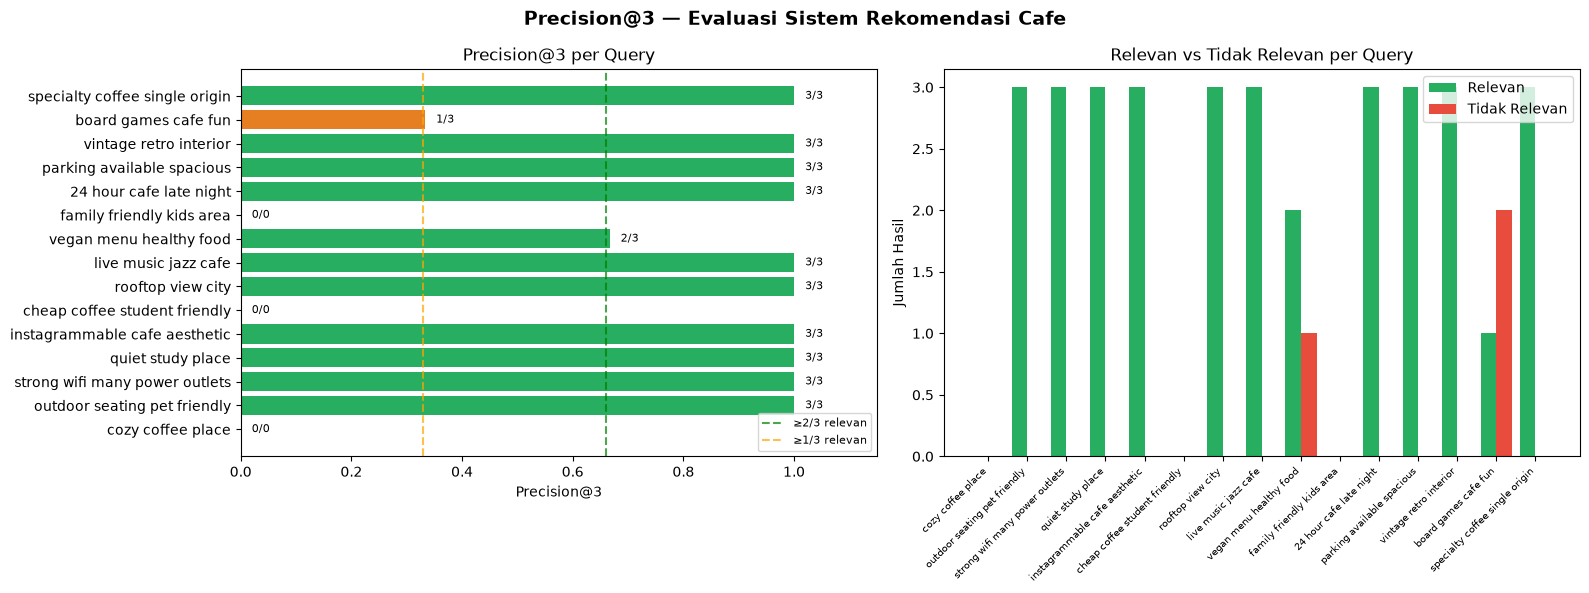


Rata-rata Precision@3 : 0.7333
Query dengan hasil penuh relevan : 10 query
Query tanpa hasil relevan        : 3 query


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Query test + threshold relevansi
TEST_QUERIES = [
    "cozy coffee place",
    "outdoor seating pet friendly",
    "strong wifi many power outlets",
    "quiet study place",
    "instagrammable cafe aesthetic",
    "cheap coffee student friendly",
    "rooftop view city",
    "live music jazz cafe",
    "vegan menu healthy food",
    "family friendly kids area",
    "24 hour cafe late night",
    "parking available spacious",
    "vintage retro interior",
    "board games cafe fun",
    "specialty coffee single origin",
]

RELEVANCE_THRESHOLD = 0.1  # skor kesesuaian minimum dianggap relevan
K = 3

precision_results = []

for query in TEST_QUERIES:
    res = get_recommendations(query, top_n=K)
    if res.empty:
        precision_results.append({'query': query, 'precision': 0.0, 'relevant': 0, 'total': 0})
        continue

    relevant = (res['Skor Kesesuaian'] >= RELEVANCE_THRESHOLD).sum()
    precision = round(relevant / len(res), 4)

    precision_results.append({
        'query':     query,
        'precision': precision,
        'relevant':  relevant,
        'total':     len(res)
    })

df_prec = pd.DataFrame(precision_results)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Precision@{K} — Evaluasi Sistem Rekomendasi Cafe', fontsize=14, fontweight='bold')

# Bar chart precision per query
colors = ['#27ae60' if p >= 0.66 else '#e67e22' if p > 0 else '#e74c3c'
          for p in df_prec['precision']]

axes[0].barh(df_prec['query'], df_prec['precision'], color=colors)
axes[0].axvline(x=0.66, color='green',  linestyle='--', alpha=0.7, label='≥2/3 relevan')
axes[0].axvline(x=0.33, color='orange', linestyle='--', alpha=0.7, label='≥1/3 relevan')
axes[0].set_xlim(0, 1.15)
axes[0].set_xlabel(f'Precision@{K}')
axes[0].set_title(f'Precision@{K} per Query')
axes[0].legend(fontsize=8)
for i, (p, r, t) in enumerate(zip(df_prec['precision'], df_prec['relevant'], df_prec['total'])):
    axes[0].text(p + 0.02, i, f'{r}/{t}', va='center', fontsize=8)


x      = np.arange(len(df_prec))
width  = 0.4
axes[1].bar(x - width/2, df_prec['relevant'],             width, label='Relevan',       color='#27ae60')
axes[1].bar(x + width/2, df_prec['total'] - df_prec['relevant'], width, label='Tidak Relevan', color='#e74c3c')
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_prec['query'], rotation=45, ha='right', fontsize=7)
axes[1].set_ylabel('Jumlah Hasil')
axes[1].set_title('Relevan vs Tidak Relevan per Query')
axes[1].legend()

plt.tight_layout()
plt.savefig('precision_at_k.png', dpi=150, bbox_inches='tight')
plt.show()

avg_prec = round(df_prec['precision'].mean(), 4)
print(f"\nRata-rata Precision@{K} : {avg_prec}")
print(f"Query dengan hasil penuh relevan : {(df_prec['precision'] == 1.0).sum()} query")
print(f"Query tanpa hasil relevan        : {(df_prec['precision'] == 0.0).sum()} query")

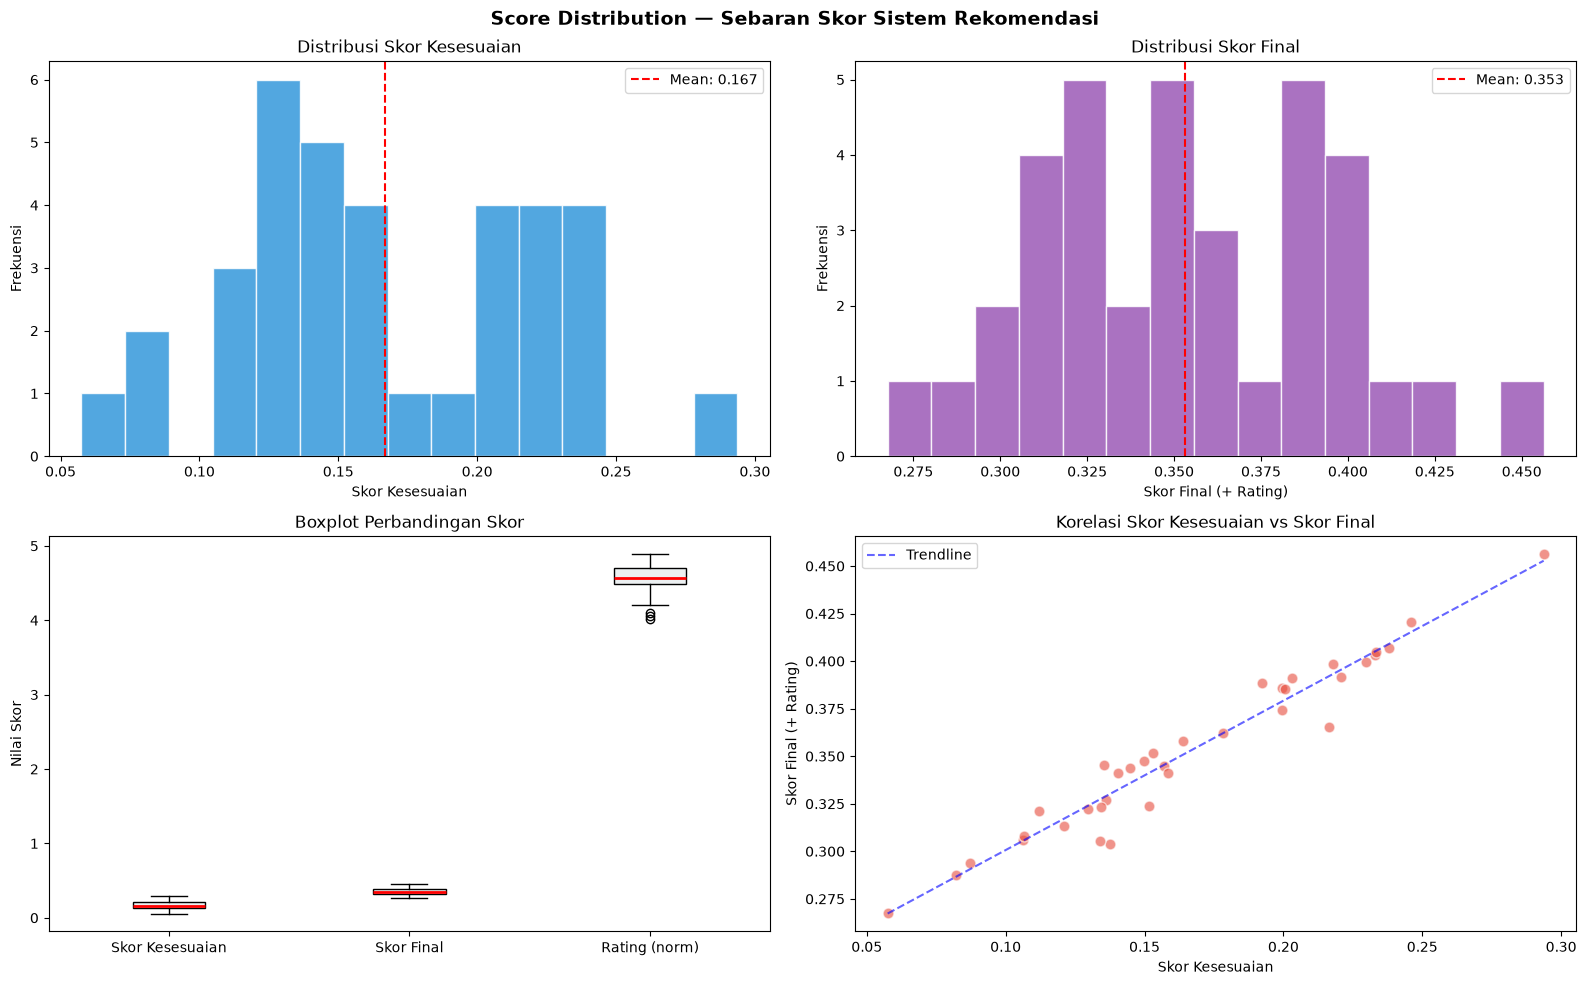


Skor Kesesuaian — Min: 0.0575  Max: 0.2937  Mean: 0.1667
Skor Final       — Min: 0.2676  Max: 0.4563  Mean: 0.3530


In [ ]:
all_kesesuaian = []
all_final      = []
all_rating     = []
query_labels   = []

for query in TEST_QUERIES:
    res = get_recommendations(query, top_n=3)
    if res.empty:
        continue
    all_kesesuaian.extend(res['Skor Kesesuaian'].tolist())
    all_final.extend(res['Skor Final (+ Rating)'].tolist())
    all_rating.extend(res['Rating Rata-rata'].tolist())
    query_labels.extend([query[:20]] * len(res))

#  Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Score Distribution — Sebaran Skor Sistem Rekomendasi', fontsize=14, fontweight='bold')

# 1. Histogram Skor Kesesuaian
axes[0, 0].hist(all_kesesuaian, bins=15, color='#3498db', edgecolor='white', alpha=0.85)
axes[0, 0].axvline(np.mean(all_kesesuaian), color='red', linestyle='--', label=f'Mean: {np.mean(all_kesesuaian):.3f}')
axes[0, 0].set_xlabel('Skor Kesesuaian')
axes[0, 0].set_ylabel('Frekuensi')
axes[0, 0].set_title('Distribusi Skor Kesesuaian')
axes[0, 0].legend()

# 2. Histogram Skor Final
axes[0, 1].hist(all_final, bins=15, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[0, 1].axvline(np.mean(all_final), color='red', linestyle='--', label=f'Mean: {np.mean(all_final):.3f}')
axes[0, 1].set_xlabel('Skor Final (+ Rating)')
axes[0, 1].set_ylabel('Frekuensi')
axes[0, 1].set_title('Distribusi Skor Final')
axes[0, 1].legend()

# 3. Boxplot perbandingan ketiga skor
axes[1, 0].boxplot(
    [all_kesesuaian, all_final, all_rating],
    tick_labels=['Skor Kesesuaian', 'Skor Final', 'Rating (norm)'],
    patch_artist=True,
    boxprops=dict(facecolor='#ecf0f1'),
    medianprops=dict(color='red', linewidth=2)
)
axes[1, 0].set_ylabel('Nilai Skor')
axes[1, 0].set_title('Boxplot Perbandingan Skor')

# 4. Scatter Skor Kesesuaian vs Skor Final
axes[1, 1].scatter(all_kesesuaian, all_final, c='#e74c3c', alpha=0.6, s=60, edgecolors='white')
axes[1, 1].set_xlabel('Skor Kesesuaian')
axes[1, 1].set_ylabel('Skor Final (+ Rating)')
axes[1, 1].set_title('Korelasi Skor Kesesuaian vs Skor Final')
z = np.polyfit(all_kesesuaian, all_final, 1)
p = np.poly1d(z)
x_line = np.linspace(min(all_kesesuaian), max(all_kesesuaian), 100)
axes[1, 1].plot(x_line, p(x_line), 'b--', alpha=0.6, label='Trendline')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSkor Kesesuaian — Min: {min(all_kesesuaian):.4f}  Max: {max(all_kesesuaian):.4f}  Mean: {np.mean(all_kesesuaian):.4f}")
print(f"Skor Final       — Min: {min(all_final):.4f}  Max: {max(all_final):.4f}  Mean: {np.mean(all_final):.4f}")

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Kumpulkan semua skor dari semua query
all_kesesuaian = []
all_final      = []
all_rating     = []
query_labels   = []

# Pastikan TEST_QUERIES dan get_recommendations sudah didefinisikan sebelumnya
for query in TEST_QUERIES:
    res = get_recommendations(query, top_n=3)
    if res.empty:
        continue
    all_kesesuaian.extend(res['Skor Kesesuaian'].tolist())
    all_final.extend(res['Skor Final (+ Rating)'].tolist())
    all_rating.extend(res['Rating Rata-rata'].tolist())
    query_labels.extend([query[:20]] * len(res))

print("=== REKAP DATA SKOR BERHASIL ===")
print(f"Skor Kesesuaian — Min: {min(all_kesesuaian):.4f}  Max: {max(all_kesesuaian):.4f}  Mean: {np.mean(all_kesesuaian):.4f}")
print(f"Skor Final      — Min: {min(all_final):.4f}  Max: {max(all_final):.4f}  Mean: {np.mean(all_final):.4f}")

=== REKAP DATA SKOR BERHASIL ===
Skor Kesesuaian — Min: 0.0575  Max: 0.2937  Mean: 0.1667
Skor Final      — Min: 0.2676  Max: 0.4563  Mean: 0.3530


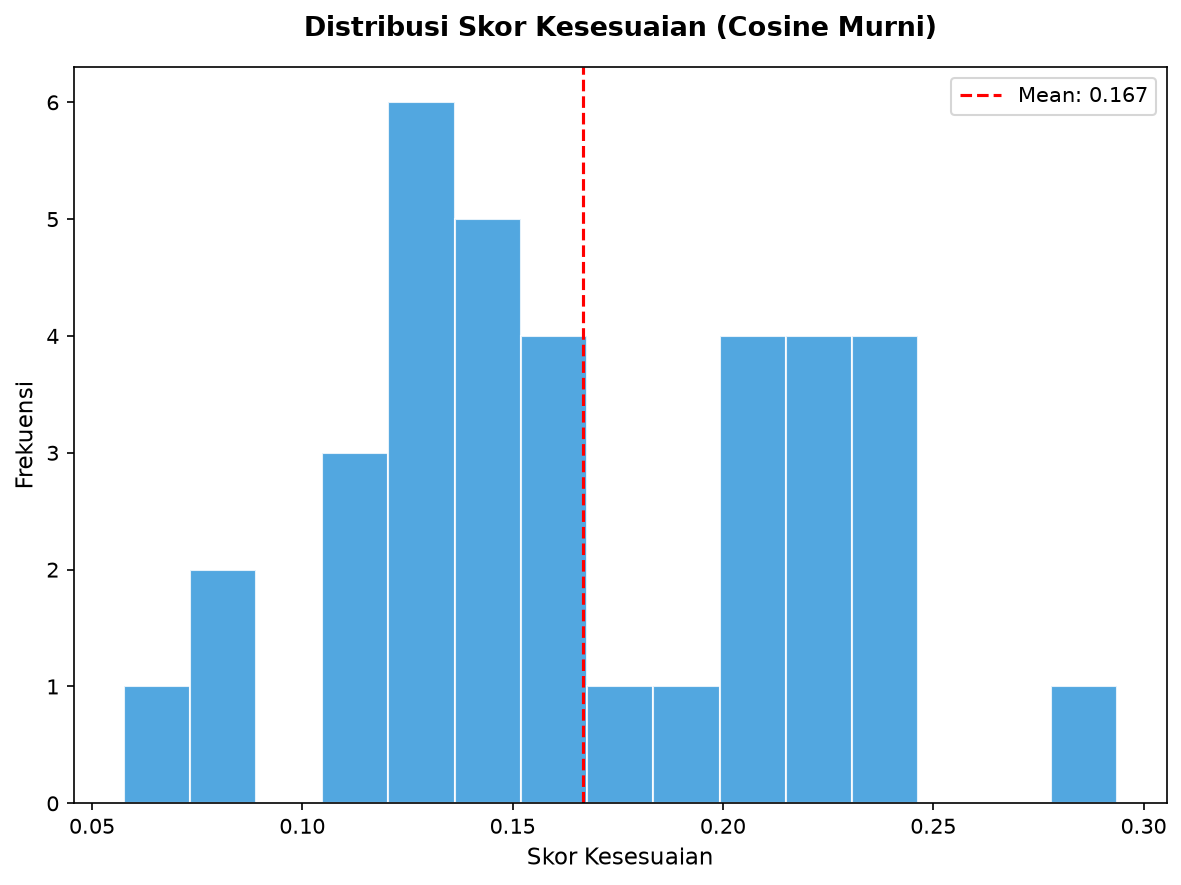

In [27]:
plt.figure(figsize=(8, 6), dpi=150)
plt.hist(all_kesesuaian, bins=15, color='#3498db', edgecolor='white', alpha=0.85)
plt.axvline(np.mean(all_kesesuaian), color='red', linestyle='--', label=f'Mean: {np.mean(all_kesesuaian):.3f}')

plt.xlabel('Skor Kesesuaian', fontsize=11)
plt.ylabel('Frekuensi', fontsize=11)
plt.title('Distribusi Skor Kesesuaian (Cosine Murni)', fontsize=13, fontweight='bold', pad=15)
plt.legend()

plt.tight_layout()
plt.savefig('distribusi_skor_kesesuaian.png', bbox_inches='tight')
plt.show()

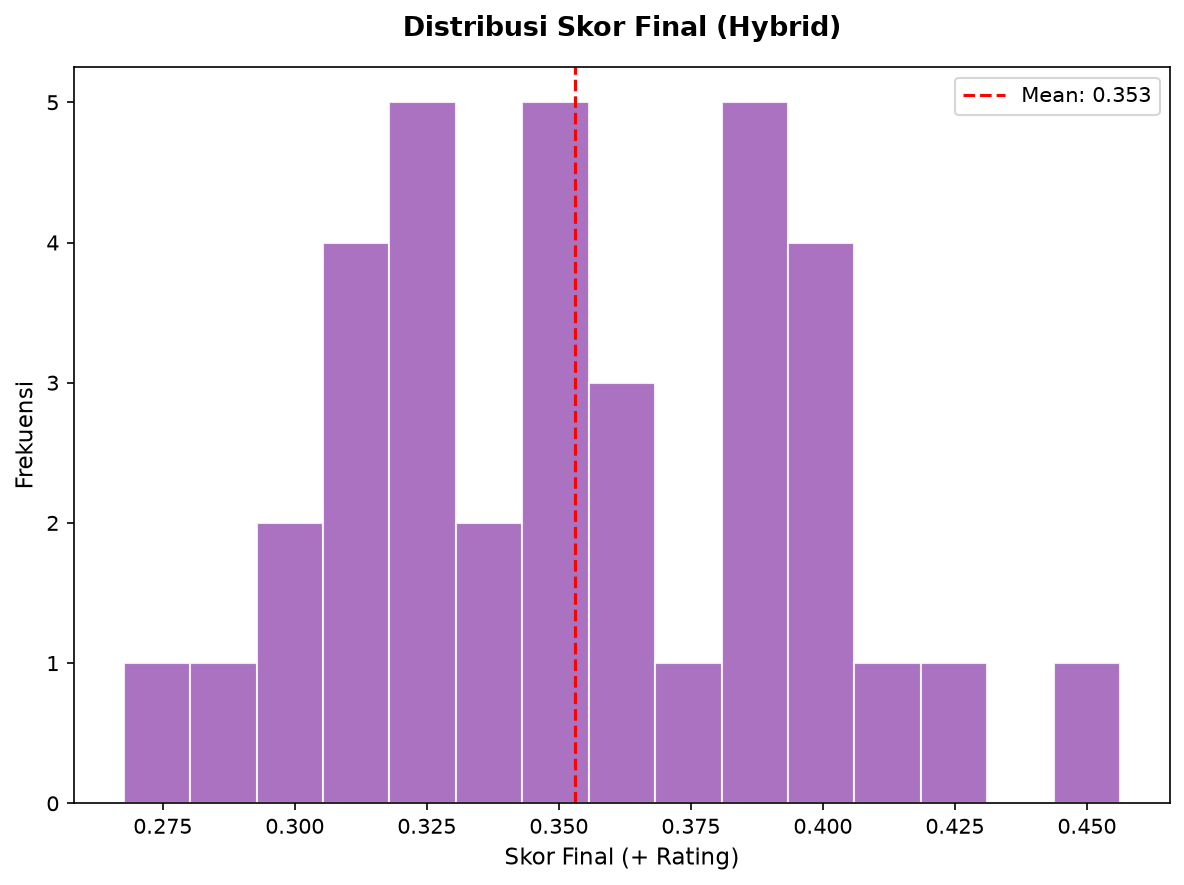

In [28]:
plt.figure(figsize=(8, 6), dpi=150)
plt.hist(all_final, bins=15, color='#9b59b6', edgecolor='white', alpha=0.85)
plt.axvline(np.mean(all_final), color='red', linestyle='--', label=f'Mean: {np.mean(all_final):.3f}')

plt.xlabel('Skor Final (+ Rating)', fontsize=11)
plt.ylabel('Frekuensi', fontsize=11)
plt.title('Distribusi Skor Final (Hybrid)', fontsize=13, fontweight='bold', pad=15)
plt.legend()

plt.tight_layout()
plt.savefig('distribusi_skor_final.png', bbox_inches='tight')
plt.show()

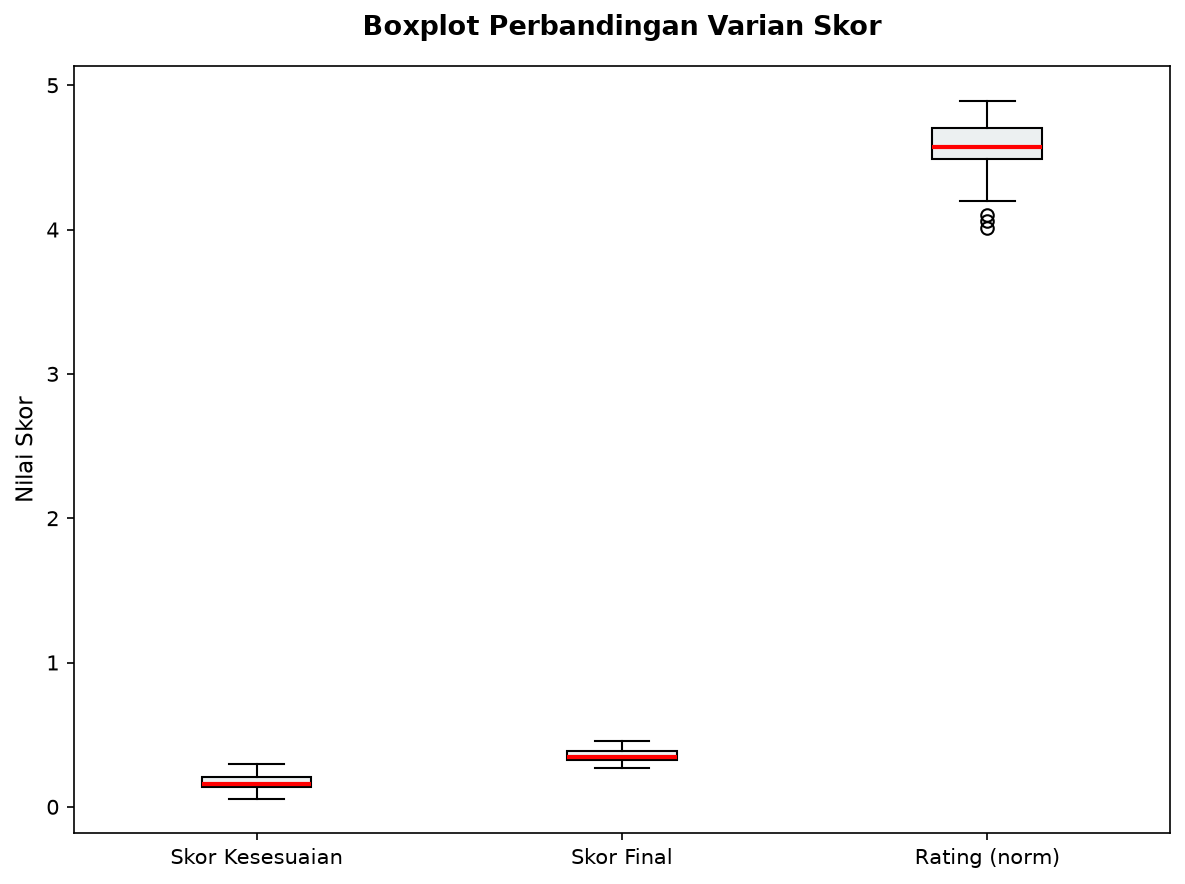

In [30]:
plt.figure(figsize=(8, 6), dpi=150)
plt.boxplot(
    [all_kesesuaian, all_final, all_rating],
    tick_labels=['Skor Kesesuaian', 'Skor Final', 'Rating (norm)'],
    patch_artist=True,
    boxprops=dict(facecolor='#ecf0f1'),
    medianprops=dict(color='red', linewidth=2)
)

plt.ylabel('Nilai Skor', fontsize=11)
plt.title('Boxplot Perbandingan Varian Skor', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('boxplot_perbandingan_skor.png', bbox_inches='tight')
plt.show()

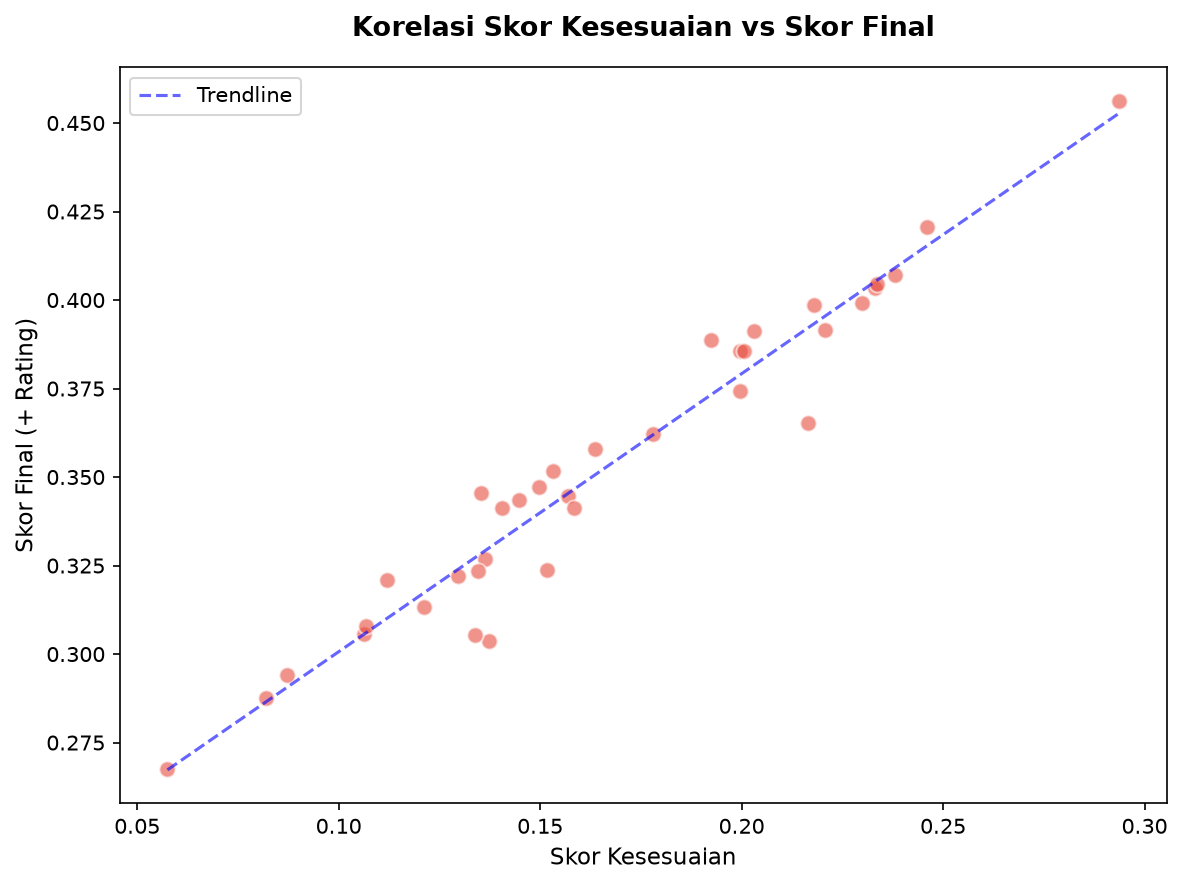

In [31]:
plt.figure(figsize=(8, 6), dpi=150)
plt.scatter(all_kesesuaian, all_final, c='#e74c3c', alpha=0.6, s=60, edgecolors='white')

z = np.polyfit(all_kesesuaian, all_final, 1)
p = np.poly1d(z)
x_line = np.linspace(min(all_kesesuaian), max(all_kesesuaian), 100)
plt.plot(x_line, p(x_line), 'b--', alpha=0.6, label='Trendline')

plt.xlabel('Skor Kesesuaian', fontsize=11)
plt.ylabel('Skor Final (+ Rating)', fontsize=11)
plt.title('Korelasi Skor Kesesuaian vs Skor Final', fontsize=13, fontweight='bold', pad=15)
plt.legend()

plt.tight_layout()
plt.savefig('scatter_korelasi_skor.png', bbox_inches='tight')
plt.show()

In [33]:
import pandas as pd

RELEVANCE_THRESHOLD = 0.1  # skor kesesuaian minimum dianggap relevan
K = 3

precision_results = []

for query in TEST_QUERIES:
    res = get_recommendations(query, top_n=K)
    if res.empty:
        precision_results.append({'query': query, 'precision': 0.0, 'relevant': 0, 'total': 0})
        continue

    relevant = (res['Skor Kesesuaian'] >= RELEVANCE_THRESHOLD).sum()
    precision = round(relevant / len(res), 4)

    precision_results.append({
        'query':     query,
        'precision': precision,
        'relevant':  relevant,
        'total':     len(res)
    })

df_prec = pd.DataFrame(precision_results)
avg_prec = round(df_prec['precision'].mean(), 4)

print("=== REKAP DATA PRECISION BERHASIL ===")
print(f"Rata-rata Precision@{K} : {avg_prec}")
print(f"Query dengan hasil penuh relevan : {(df_prec['precision'] == 1.0).sum()} query")
print(f"Query tanpa hasil relevan        : {(df_prec['precision'] == 0.0).sum()} query")

=== REKAP DATA PRECISION BERHASIL ===
Rata-rata Precision@3 : 0.7333
Query dengan hasil penuh relevan : 10 query
Query tanpa hasil relevan        : 3 query


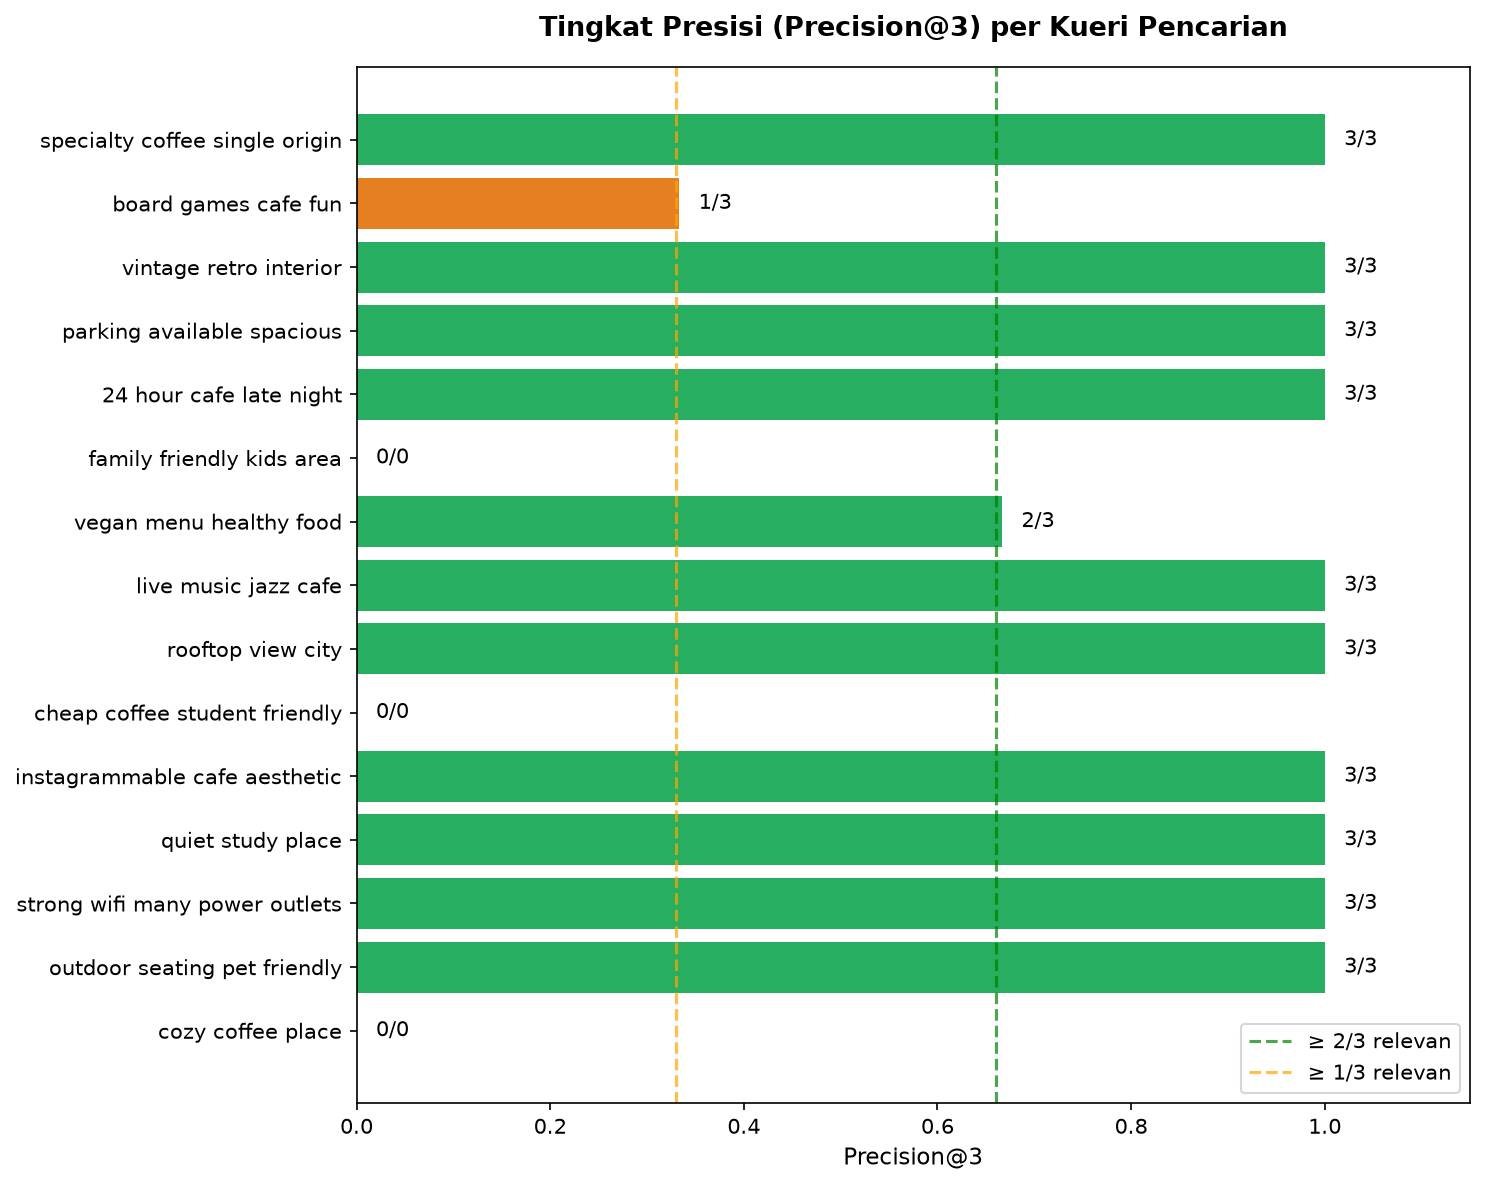

In [34]:
plt.figure(figsize=(10, 8), dpi=150)

colors = ['#27ae60' if p >= 0.66 else '#e67e22' if p > 0 else '#e74c3c' for p in df_prec['precision']]

plt.barh(df_prec['query'], df_prec['precision'], color=colors)
plt.axvline(x=0.66, color='green',  linestyle='--', alpha=0.7, label='≥ 2/3 relevan')
plt.axvline(x=0.33, color='orange', linestyle='--', alpha=0.7, label='≥ 1/3 relevan')

plt.xlim(0, 1.15)
plt.xlabel(f'Precision@{K}', fontsize=11)
plt.title(f'Tingkat Presisi (Precision@{K}) per Kueri Pencarian', fontsize=13, fontweight='bold', pad=15)
plt.legend(fontsize=10)

for i, (p, r, t) in enumerate(zip(df_prec['precision'], df_prec['relevant'], df_prec['total'])):
    plt.text(p + 0.02, i, f'{r}/{t}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('precision_per_query.png', bbox_inches='tight')
plt.show()

In [36]:
import time
import re
import numpy as np
import pandas as pd
from sklearn.metrics import ndcg_score
from groq import Groq

pd.set_option('display.max_colwidth', None)

import os
from dotenv import load_dotenv
load_dotenv()
API_KEY = os.getenv("GROQ_API_KEY")
client = Groq(api_key=API_KEY)


# 1. MEMBUAT DATA EVALUASI
print("Membuat tabel rekomendasi untuk dievaluasi...")
daftar_kueri_tes = [
    "cozy coffee place",
    "outdoor seating pet friendly",
    "strong wifi many power outlets",
    "quiet study place",
    "instagrammable cafe aesthetic",
    "cheap coffee student friendly",
    "rooftop view city",
    "live music jazz cafe",
    "vegan menu healthy food",
    "family friendly kids area",
    "24 hour cafe late night",
    "parking available spacious",
    "vintage retro interior",
    "board games cafe fun",
    "specialty coffee single origin",
]

list_hasil_df = []

for kueri in daftar_kueri_tes:
    rek_df = get_recommendations(kueri, top_n=3)

    if not rek_df.empty:
        rek_df['Kueri'] = kueri
        rek_df['Ranking'] = range(1, len(rek_df) + 1)
        list_hasil_df.append(rek_df)

if len(list_hasil_df) > 0:
    df_evaluasi = pd.concat(list_hasil_df, ignore_index=True)
    print("Tabel df_evaluasi berhasil dibuat!")
else:
    print("Gagal membuat tabel evaluasi: Tidak ada rekomendasi yang ditemukan.")
    df_evaluasi = pd.DataFrame()

# 2. FUNGSI EVALUASI LLM MENGGUNAKAN GROQ
def nilai_relevansi_dengan_groq(kueri, teks_ulasan):
    prompt = f"""
    Tugas Anda menilai relevansi ulasan kafe terhadap kueri pencarian.
    Berikan skor 1 (Tidak Relevan), 2 (Cukup), atau 3 (Sangat Relevan).

    Kueri: '{kueri}'
    Ulasan: '{teks_ulasan}'

    Balas WAJIB dengan format berikut (tanpa tambahan kalimat lain):
    SKOR: [angka]
    ALASAN: [penjelasan singkat maksimal 1 kalimat]
    """

    try:
        response = client.chat.completions.create(
            messages=[{"role": "user", "content": prompt}],
            model="llama-3.1-8b-instant",
            temperature=0.0,
        )

        hasil_teks = response.choices[0].message.content

        skor = 1
        alasan = hasil_teks.replace('\n', ' ')[:200]

        if "SKOR:" in hasil_teks.upper():
            match_skor = re.search(r'SKOR:\s*([123])', hasil_teks, re.IGNORECASE)
            if match_skor:
                skor = int(match_skor.group(1))

            match_alasan = re.split(r'ALASAN:', hasil_teks, flags=re.IGNORECASE)
            if len(match_alasan) > 1:
                alasan = match_alasan[1].strip()

        time.sleep(1)
        return skor, alasan

    except Exception as e:
        print(f"Error API Groq: {e}")
        return 1, "Gagal dievaluasi AI (Error Sistem)."


# 3. PROSES EKSEKUSI EVALUASI & KALKULASI NDCG
if not df_evaluasi.empty:
    if API_KEY == "MASUKKAN_API_KEY_GROQ_ANDA_DISINI":
        print("\n[!] PERINGATAN: Anda belum memasukkan API Key Groq!")
    else:
        print("\nMemulai Evaluasi dengan AI Groq (LLaMA 3.1)...\n" + "="*50)

    skor_llm_list = []
    alasan_list = []

    for index, row in df_evaluasi.iterrows():
        kueri = row['Kueri']
        ulasan = row.get('Kutipan Ulasan', '')

        if index == 0 or df_evaluasi.iloc[index-1]['Kueri'] != kueri:
            print(f"\nMengevaluasi Kueri: '{kueri}'...")

        skor, alasan = nilai_relevansi_dengan_groq(kueri, ulasan)
        skor_llm_list.append(skor)
        alasan_list.append(alasan)

        print(f"  -> Rank {row['Ranking']}: Skor AI = {skor}")

    df_evaluasi['Skor LLM'] = skor_llm_list
    df_evaluasi['Alasan AI'] = alasan_list

    ndcg_scores = []
    for kueri, group in df_evaluasi.groupby('Kueri'):
        true_relevance = np.asarray([group['Skor LLM'].values])
        n_items = len(group)
        predicted_relevance = np.asarray([[3, 2, 1][:n_items]])

        if n_items > 1:
            score = ndcg_score(true_relevance, predicted_relevance)
            ndcg_scores.append(score)
        else:
            ndcg_scores.append(1.0)

    mean_ndcg = np.mean(ndcg_scores) if ndcg_scores else 0.0

    print("\n" + "="*70)
    print(f"SKOR AKHIR SISTEM (NDCG): {mean_ndcg:.4f}")
    print("="*70)


    # 4. MENAMPILKAN TABEL TRANSPARAN (Sistem vs AI Judge)
    kolom_tampil = [
        'Kueri',
        'Ranking',
        'Nama Cafe',
        'Kutipan Ulasan',
        'Skor Final (+ Rating)',
        'Skor LLM',
        'Alasan AI'
    ]


    df_tampil = df_evaluasi[[kol for kol in kolom_tampil if kol in df_evaluasi.columns]]

    display(df_tampil)

Membuat tabel rekomendasi untuk dievaluasi...
Tabel df_evaluasi berhasil dibuat!

Memulai Evaluasi dengan AI Groq (LLaMA 3.1)...

Mengevaluasi Kueri: 'outdoor seating pet friendly'...
Error API Groq: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'expired_api_key'}}
  -> Rank 1: Skor AI = 1
Error API Groq: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'expired_api_key'}}
  -> Rank 2: Skor AI = 1
Error API Groq: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'expired_api_key'}}
  -> Rank 3: Skor AI = 1

Mengevaluasi Kueri: 'strong wifi many power outlets'...
Error API Groq: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'expired_api_key'}}
  -> Rank 1: Skor AI = 1
Error API Groq: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code':

,Kueri,Ranking,Nama Cafe,Kutipan Ulasan,Skor Final (+ Rating),Skor LLM,Alasan AI
0,outdoor seating pet friendly,1,LCC - Lucy Curated Compound Adityawarman,Good place to hang out with friends and family. Was there in uncrowded time between lunch time and tea time. The indoor upstairs was kind of damp and hot. Air con was not doing its job properly. Many food stalls to choose with a friendly face and se...,0.3221,1,Gagal dievaluasi AI (Error Sistem).
1,outdoor seating pet friendly,2,Titik Koma Tanjung Duren,"Titik Koma Tanjung Duren Stumbled upon this gem tucked away in a residential area in Tanjung Duren. The vibe is inviting, features a modern, cozy design with warm wooden elements, lush plants, and abundant of natural light. Tried their Es Kopi Sus...",0.3210,1,Gagal dievaluasi AI (Error Sistem).
2,outdoor seating pet friendly,3,Salty Salty,"taste so good for the matcha, coffee was okay. Havent tried the chocolate. the place a little bit too small, pet friendly i guess. Dont usually like marshmallows but this one taste good",0.3133,1,Gagal dievaluasi AI (Error Sistem).
3,strong wifi many power outlets,1,Morning Blues,"My all time favorite working place in West Jakarta. Strong wifi connection, calming yet busy vibe, not too noisy/crowded, great natural and indoor lighting, decent menu with varieties, power outlets, friendly staff. The toilet is outside, in the apar...",0.4563,1,Gagal dievaluasi AI (Error Sistem).
4,strong wifi many power outlets,2,Oddity Coffee,"Loved the ambience, perfect for wfc. The second floor has long seatings with tons of power outlet. The coffee was great, i ordered americano with classic blend. The korean garlic croissant was also nice. Recommended for another wfc session or group h...",0.3436,1,Gagal dievaluasi AI (Error Sistem).
5,strong wifi many power outlets,3,Anomali Coffee Menteng,"Went here 9AM Tuesday for work, not so crowded at the moment. Located near RS Bunda Cikini, accessible by bus and car & bike parking is ample. Outdoor seating is a lot and well-cooled by fans, indoor seating as well. Wifi is strong, but electric plug...",0.3057,1,Gagal dievaluasi AI (Error Sistem).
6,quiet study place,1,Tyfel Coffee,"Finally, after a long time since this café moved locations, I was able to come here again. I came here for iftar with my friends, and we got a Ramadan package promotion which includes pasta and ice tea for only 50k/person. The main menu variants are...",0.4033,1,Gagal dievaluasi AI (Error Sistem).
7,quiet study place,2,Oddity Coffee,"Came on a saturday evening for a hangout. The atmosphere was nice and comfy. The staffs were nice and really informative. We ordered Salted Foam Cocoa, Spicy Popcorn Chicken and Bakmi Ayam Jakarta. The salted foam cocoa was interesting. The salted f...",0.3985,1,Gagal dievaluasi AI (Error Sistem).
8,quiet study place,3,KOZI Coffee 3.7 Jeruk Purut,"A fantastic cafe for studying or working, offering plenty of outlets, a blend of natural outdoor seating and cozy indoor spaces, friendly staff, and a great selection of local and international coffee.",0.3857,1,Gagal dievaluasi AI (Error Sistem).
9,instagrammable cafe aesthetic,1,Copper Club Specialty Coffee,"Tue, Oct 27 2020. Comfort place to have a meeting or just grab a delicious coffee on a weekend. So I've just tried its Choco chips drink (IDR 45k), beef fried rice (IDR 50k) & korean garlic bread (IDR 50k), it has standard taste, not perfect but not ...",0.3912,1,Gagal dievaluasi AI (Error Sistem).


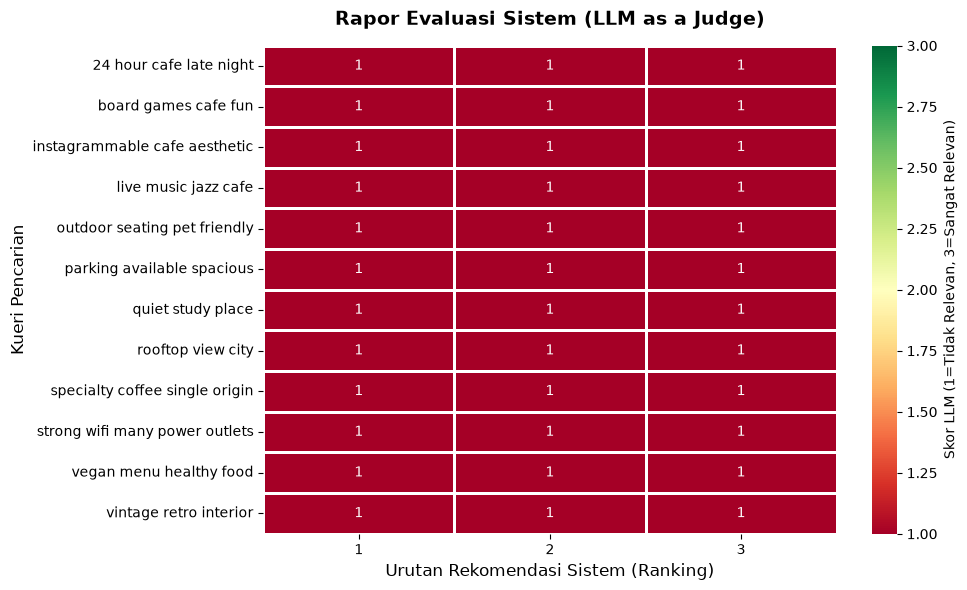

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if not df_tampil.empty:
    # Mengubah format data tabel menjadi matrix untuk Heatmap
    # Baris (index) = Kueri, Kolom (columns) = Ranking, Nilai (values) = Skor LLM
    heatmap_data = df_tampil.pivot(index="Kueri", columns="Ranking", values="Skor LLM")

    plt.figure(figsize=(10, 6))

    # Membuat Heatmap
    # cmap = warna (RdYlGn = Red, Yellow, Green) -> Cocok untuk skor buruk ke baik
    ax = sns.heatmap(
        heatmap_data,
        annot=True,         # Menampilkan angka di dalam kotak
        cmap="RdYlGn",      # Merah (1) -> Kuning (2) -> Hijau (3)
        vmin=1, vmax=3,     # Batas skor minimum 1, maksimum 3
        cbar_kws={'label': 'Skor LLM (1=Tidak Relevan, 3=Sangat Relevan)'},
        linewidths=1,       # Garis antar kotak
        linecolor='white'
    )

    plt.title("Rapor Evaluasi Sistem (LLM as a Judge)", fontweight='bold', fontsize=14, pad=15)
    plt.xlabel("Urutan Rekomendasi Sistem (Ranking)", fontsize=12)
    plt.ylabel("Kueri Pencarian", fontsize=12)

    # Memperbaiki rotasi teks agar mudah dibaca
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada data untuk dibuatkan grafik.")

In [38]:
import numpy as np
import pandas as pd
from sklearn.metrics import ndcg_score
from sklearn.metrics.pairwise import cosine_similarity

y_true_all = []
y_score_baseline = []
y_score_alt1 = []
y_score_alt2 = []
y_score_alt3 = []

print("Mulai menghitung evaluasi NDCG untuk 4 formula pada model yang direvisi...\n")

for kueri, group in df_evaluasi.groupby('Kueri'):

    cleaned_key = clean_text(kueri)
    keyword_vec = tfidf.transform([cleaned_key])
    semua_cosine = cosine_similarity(keyword_vec, tfidf_matrix).flatten()

    y_true_query = []
    y_base_q, y_alt1_q, y_alt2_q, y_alt3_q = [], [], [], []

    for _, row in group.iterrows():
        nama_kafe = row['Nama Cafe']
        skor_llm = int(row['Skor LLM'])

        # Cari index kafe
        idx_kafe = cafe_profiles[cafe_profiles['cafe_name'] == nama_kafe].index[0]

        # Ambil nilai Cosine BARU (hasil preprocessing revisi) dan Rating
        cosine_score = semua_cosine[idx_kafe]
        rating_asli = cafe_profiles.loc[idx_kafe, 'avg_rating']
        rating_normal = rating_asli / 5.0

        # --- PERHITUNGAN 4 FORMULA ---

        # Formula 1: Baseline (75% Teks : 25% Rating)
        s_base = (cosine_score * 0.75) + (rating_normal * 0.25)

        # Formula 2: Alt 1 (90% Teks : 10% Rating)
        s_alt1 = (cosine_score * 0.90) + (rating_normal * 0.10)

        # Formula 3: Alt 2 (Multiplicative / Penalty)
        s_alt2 = cosine_score * rating_normal

        # Formula 4: Alt 3 (Thresholding > 0.1)
        if cosine_score < 0.1:
            s_alt3 = cosine_score
        else:
            s_alt3 = cosine_score + ((rating_asli - 3.0) * 0.05)

        # Simpan skor untuk kueri ini
        y_true_query.append(skor_llm)
        y_base_q.append(s_base)
        y_alt1_q.append(s_alt1)
        y_alt2_q.append(s_alt2)
        y_alt3_q.append(s_alt3)

    y_true_all.append(y_true_query)
    y_score_baseline.append(y_base_q)
    y_score_alt1.append(y_alt1_q)
    y_score_alt2.append(y_alt2_q)
    y_score_alt3.append(y_alt3_q)

# Menghitung NDCG Akhir
ndcg_base = ndcg_score(np.array(y_true_all), np.array(y_score_baseline))
ndcg_alt1 = ndcg_score(np.array(y_true_all), np.array(y_score_alt1))
ndcg_alt2 = ndcg_score(np.array(y_true_all), np.array(y_score_alt2))
ndcg_alt3 = ndcg_score(np.array(y_true_all), np.array(y_score_alt3))

print("="*50)
print("HASIL EVALUASI NDCG (MODEL REVISI)")
print("="*50)
print(f"1. Baseline (75:25)                   : {ndcg_base:.4f}")
print(f"2. Alt 1 (Penjumlahan Dinamis 90:10)  : {ndcg_alt1:.4f}")
print(f"3. Alt 2 (Metode Perkalian/Penalty)   : {ndcg_alt2:.4f}")
print(f"4. Alt 3 (Metode Thresholding > 0.1)  : {ndcg_alt3:.4f}")
print("="*50)

Mulai menghitung evaluasi NDCG untuk 4 formula pada model yang direvisi...

HASIL EVALUASI NDCG (MODEL REVISI)
1. Baseline (75:25)                   : 1.0000
2. Alt 1 (Penjumlahan Dinamis 90:10)  : 1.0000
3. Alt 2 (Metode Perkalian/Penalty)   : 1.0000
4. Alt 3 (Metode Thresholding > 0.1)  : 1.0000


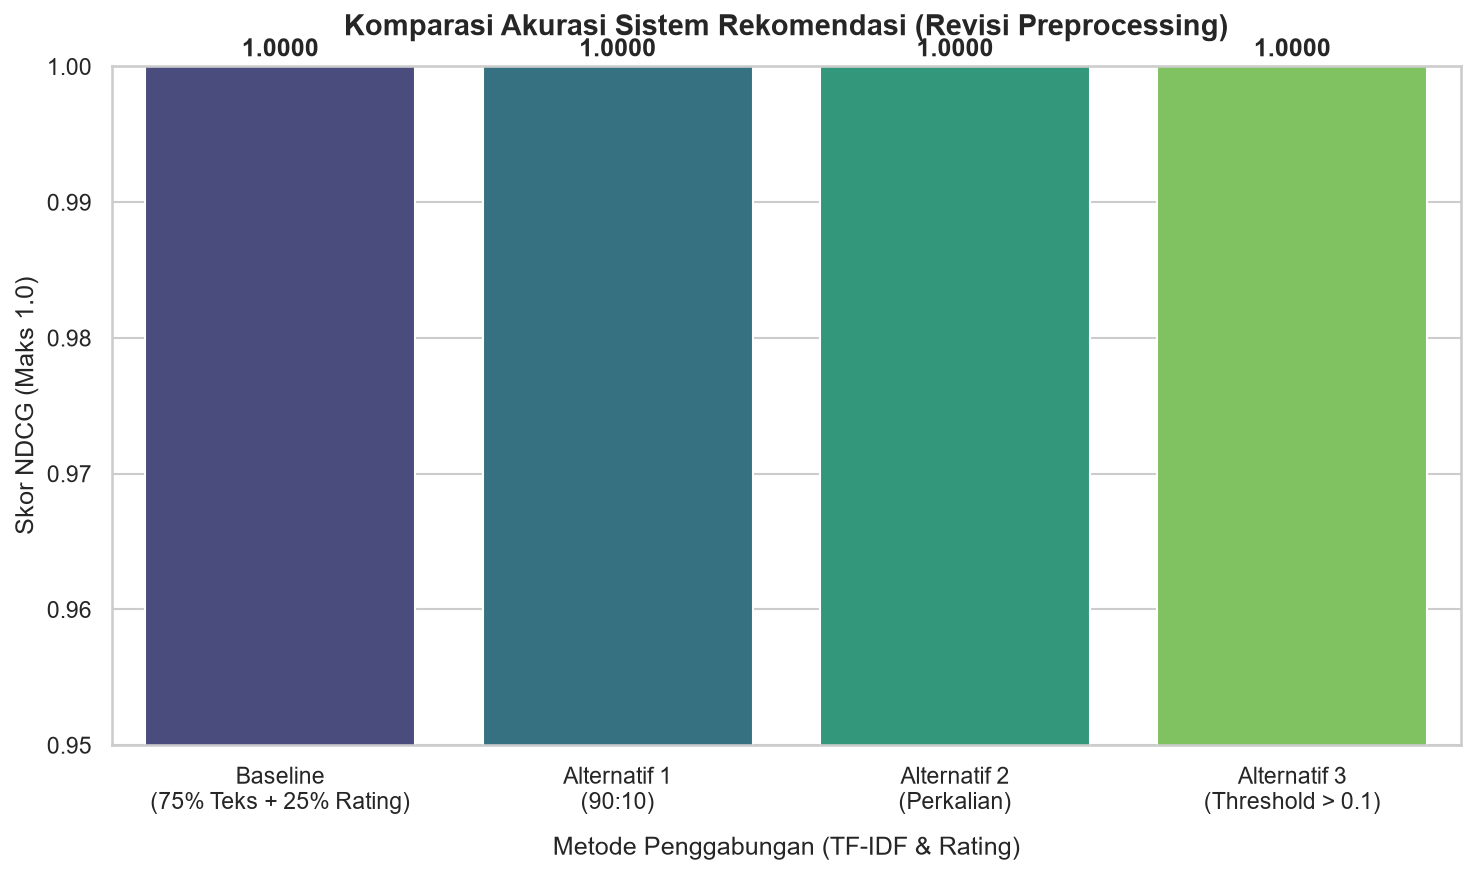

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data_evaluasi = {
    'Formula Scoring': [
        'Baseline\n(75% Teks + 25% Rating)',
        'Alternatif 1\n(90:10)',
        'Alternatif 2\n(Perkalian)',
        'Alternatif 3\n(Threshold > 0.1)'
    ],
    'Skor NDCG': [ndcg_base, ndcg_alt1, ndcg_alt2, ndcg_alt3]
}

df_grafik = pd.DataFrame(data_evaluasi)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6), dpi=150)

ax = sns.barplot(
    x='Formula Scoring',
    y='Skor NDCG',
    data=df_grafik,
    palette='viridis',
    hue='Formula Scoring',
    legend=False
)

plt.title('Komparasi Akurasi Sistem Rekomendasi (Revisi Preprocessing)',
          fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Metode Penggabungan (TF-IDF & Rating)', fontsize=12, labelpad=10)
plt.ylabel('Skor NDCG (Maks 1.0)', fontsize=12)

min_score = min(data_evaluasi['Skor NDCG'])
plt.ylim(min_score - 0.05, 1.0)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontweight='bold')

plt.tight_layout()
plt.show()